## Part A: Data Splitting and Evaluation

### 1. Choose a dataset (Fashion-MNIST)

In [1]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load the Fashion-MNIST dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

print(f"Full training data shape: {x_train_full.shape}")
print(f"Full training labels shape: {y_train_full.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Full training data shape: (60000, 28, 28)
Full training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


### 2. Split the data into training, validation, and testing sets

In [2]:
# Split the full training data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Validation data shape: {x_val.shape}")
print(f"Validation labels shape: {y_val.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Training data shape: (48000, 28, 28)
Training labels shape: (48000,)
Validation data shape: (12000, 28, 28)
Validation labels shape: (12000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


### 3. Build a baseline model

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Define the baseline model architecture
baseline_model = Sequential([
    Flatten(input_shape=(28, 28)), # Input layer: flatten 28x28 images into a 784-dimensional vector
    Dense(128, activation='relu'), # Hidden layer with 128 neurons and ReLU activation
    Dense(10, activation='softmax') # Output layer with 10 neurons (for 10 classes) and softmax activation
])

# Compile the model
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display the model summary
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Train the baseline model and evaluate its performance

In [4]:
# Train the baseline model
baseline_history = baseline_model.fit(
    x_train, y_train,
    epochs=10, # Train for 10 epochs (can be adjusted)
    validation_data=(x_val, y_val)
)

# Evaluate the model on the test set
loss, accuracy = baseline_model.evaluate(x_test, y_test)
print(f"\nBaseline Test Loss: {loss:.4f}")
print(f"Baseline Test Accuracy: {accuracy:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8179 - loss: 0.5165 - val_accuracy: 0.8659 - val_loss: 0.3840
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8605 - loss: 0.3868 - val_accuracy: 0.8562 - val_loss: 0.3919
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8748 - loss: 0.3448 - val_accuracy: 0.8801 - val_loss: 0.3355
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8830 - loss: 0.3204 - val_accuracy: 0.8773 - val_loss: 0.3494
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8876 - loss: 0.3045 - val_accuracy: 0.8913 - val_loss: 0.3119
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8940 - loss: 0.2870 - val_accuracy: 0.8823 - val_loss: 0.3357
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8995 - loss: 0.2731 - val_accuracy: 0.8900 - val_loss: 0.3138
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9009 - loss: 0.2639 - 

## Part B: Mitigating Overfitting

### 1. Implement Regularization (L2 Regularization)

In [7]:
from tensorflow.keras.regularizers import l2

# Define a model with L2 regularization
regularized_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)), # L2 regularization added
    Dense(10, activation='softmax')
])

# Compile the model
regularized_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

regularized_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### 2. Train the regularized model and evaluate its performance

In [8]:
# Train the regularized model
regularized_history = regularized_model.fit(
    x_train, y_train,
    epochs=10, # Same number of epochs as baseline
    validation_data=(x_val, y_val)
)

# Evaluate the regularized model on the test set
reg_loss, reg_accuracy = regularized_model.evaluate(x_test, y_test)
print(f"\nRegularized Test Loss: {reg_loss:.4f}")
print(f"Regularized Test Accuracy: {reg_accuracy:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8130 - loss: 0.6651 - val_accuracy: 0.8445 - val_loss: 0.5376
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8453 - loss: 0.5241 - val_accuracy: 0.8664 - val_loss: 0.4755
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8548 - loss: 0.4862 - val_accuracy: 0.8629 - val_loss: 0.4728
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8574 - loss: 0.4708 - val_accuracy: 0.8631 - val_loss: 0.4590
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8615 - loss: 0.4576 - val_accuracy: 0.8661 - val_loss: 0.4523
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8635 - loss: 0.4514 - val_accuracy: 0.8680 - val_loss: 0.4465
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8671 - loss: 0.4406 - val_accuracy: 0.8556 - val_loss: 0.4683
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8684 - loss: 0.4328 - 

## Part B: Mitigating Overfitting

### 1. Implement Regularization (L2 Regularization)

In [5]:
from tensorflow.keras.regularizers import l2

# Define a model with L2 regularization
regularized_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)), # L2 regularization added
    Dense(10, activation='softmax')
])

# Compile the model
regularized_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

regularized_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### 2. Train the regularized model and evaluate its performance

In [6]:
# Train the regularized model
regularized_history = regularized_model.fit(
    x_train, y_train,
    epochs=10, # Same number of epochs as baseline
    validation_data=(x_val, y_val)
)

# Evaluate the regularized model on the test set
reg_loss, reg_accuracy = regularized_model.evaluate(x_test, y_test)
print(f"\nRegularized Test Loss: {reg_loss:.4f}")
print(f"Regularized Test Accuracy: {reg_accuracy:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8113 - loss: 0.6719 - val_accuracy: 0.8389 - val_loss: 0.5568
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8464 - loss: 0.5223 - val_accuracy: 0.8582 - val_loss: 0.4905
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8512 - loss: 0.4916 - val_accuracy: 0.8648 - val_loss: 0.4597
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8587 - loss: 0.4695 - val_accuracy: 0.8723 - val_loss: 0.4435
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8621 - loss: 0.4583 - val_accuracy: 0.8672 - val_loss: 0.4453
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8654 - loss: 0.4481 - val_accuracy: 0.8702 - val_loss: 0.4396
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8675 - loss: 0.4380 - val_accuracy: 0.8747 - val_loss: 0.4316
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8676 - loss: 0.4345 - 

### 3. Add Dropout Layers

In [11]:
from tensorflow.keras.layers import Dropout

# Define a model with Dropout layers
dropout_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dropout(0.3), # Dropout layer with 30% dropout rate
    Dense(10, activation='softmax')
])

# Compile the model
dropout_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

dropout_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Train the model with Dropout and evaluate its performance

In [12]:
# Train the dropout model
dropout_history = dropout_model.fit(
    x_train, y_train,
    epochs=10, # Same number of epochs as baseline
    validation_data=(x_val, y_val)
)

# Evaluate the dropout model on the test set
drop_loss, drop_accuracy = dropout_model.evaluate(x_test, y_test)
print(f"\nDropout Test Loss: {drop_loss:.4f}")
print(f"Dropout Test Accuracy: {drop_accuracy:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7975 - loss: 0.5781 - val_accuracy: 0.8611 - val_loss: 0.4036
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8432 - loss: 0.4372 - val_accuracy: 0.8645 - val_loss: 0.3767
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8535 - loss: 0.4015 - val_accuracy: 0.8754 - val_loss: 0.3434
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8614 - loss: 0.3773 - val_accuracy: 0.8778 - val_loss: 0.3349
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8677 - loss: 0.3560 - val_accuracy: 0.8803 - val_loss: 0.3318
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8726 - loss: 0.3461 - val_accuracy: 0.8819 - val_loss: 0.3253
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8748 - loss: 0.3389 - val_accuracy: 0.8832 - val_loss: 0.3288
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8792 - loss: 0.3281 -

### 3. Add Dropout Layers

In [9]:
from tensorflow.keras.layers import Dropout

# Define a model with Dropout layers
dropout_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dropout(0.3), # Dropout layer with 30% dropout rate
    Dense(10, activation='softmax')
])

# Compile the model
dropout_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

dropout_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Train the model with Dropout and evaluate its performance

In [10]:
# Train the dropout model
dropout_history = dropout_model.fit(
    x_train, y_train,
    epochs=10, # Same number of epochs as baseline
    validation_data=(x_val, y_val)
)

# Evaluate the dropout model on the test set
drop_loss, drop_accuracy = dropout_model.evaluate(x_test, y_test)
print(f"\nDropout Test Loss: {drop_loss:.4f}")
print(f"Dropout Test Accuracy: {drop_accuracy:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7974 - loss: 0.5760 - val_accuracy: 0.8503 - val_loss: 0.4163
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8441 - loss: 0.4325 - val_accuracy: 0.8630 - val_loss: 0.3726
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8541 - loss: 0.3965 - val_accuracy: 0.8707 - val_loss: 0.3599
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8634 - loss: 0.3724 - val_accuracy: 0.8798 - val_loss: 0.3415
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8658 - loss: 0.3600 - val_accuracy: 0.8757 - val_loss: 0.3403
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8717 - loss: 0.3467 - val_accuracy: 0.8801 - val_loss: 0.3310
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8746 - loss: 0.3352 - val_accuracy: 0.8810 - val_loss: 0.3325
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8772 - loss: 0.3260 - 

### 5. Use Batch Normalization

In [15]:
from tensorflow.keras.layers import BatchNormalization

# Define a model with Batch Normalization layers
bn_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    BatchNormalization(), # Batch Normalization layer added
    Dense(10, activation='softmax')
])

# Compile the model
bn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bn_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,282 (399.54 KB)

 Trainable params: 102,026 (398.54 KB)

 Non-trainable params: 256 (1.00 KB)

### 6. Train the model with Batch Normalization and evaluate its performance

In [16]:
# Train the Batch Normalization model
bn_history = bn_model.fit(
    x_train, y_train,
    epochs=10, # Same number of epochs as baseline
    validation_data=(x_val, y_val)
)

# Evaluate the Batch Normalization model on the test set
bn_loss, bn_accuracy = bn_model.evaluate(x_test, y_test)
print(f"\nBatch Normalization Test Loss: {bn_loss:.4f}")
print(f"Batch Normalization Test Accuracy: {bn_accuracy:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8252 - loss: 0.5038 - val_accuracy: 0.8508 - val_loss: 0.4400
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8509 - loss: 0.4144 - val_accuracy: 0.8435 - val_loss: 0.4252
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8636 - loss: 0.3776 - val_accuracy: 0.8692 - val_loss: 0.3736
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8708 - loss: 0.3583 - val_accuracy: 0.8702 - val_loss: 0.3551
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8746 - loss: 0.3409 - val_accuracy: 0.8715 - val_loss: 0.3562
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8801 - loss: 0.3291 - val_accuracy: 0.8796 - val_loss: 0.3500
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8842 - loss: 0.3189 - val_accuracy: 0.8759 - val_loss: 0.3467
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8872 - loss: 0.3109 -

### 5. Use Batch Normalization

In [13]:
from tensorflow.keras.layers import BatchNormalization

# Define a model with Batch Normalization layers
bn_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    BatchNormalization(), # Batch Normalization layer added
    Dense(10, activation='softmax')
])

# Compile the model
bn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,282 (399.54 KB)

 Trainable params: 102,026 (398.54 KB)

 Non-trainable params: 256 (1.00 KB)

### 6. Train the model with Batch Normalization and evaluate its performance

In [14]:
# Train the Batch Normalization model
bn_history = bn_model.fit(
    x_train, y_train,
    epochs=10, # Same number of epochs as baseline
    validation_data=(x_val, y_val)
)

# Evaluate the Batch Normalization model on the test set
bn_loss, bn_accuracy = bn_model.evaluate(x_test, y_test)
print(f"\nBatch Normalization Test Loss: {bn_loss:.4f}")
print(f"Batch Normalization Test Accuracy: {bn_accuracy:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8218 - loss: 0.5093 - val_accuracy: 0.8359 - val_loss: 0.4744
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8499 - loss: 0.4158 - val_accuracy: 0.8506 - val_loss: 0.4129
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8603 - loss: 0.3890 - val_accuracy: 0.8464 - val_loss: 0.4369
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8673 - loss: 0.3659 - val_accuracy: 0.8442 - val_loss: 0.4433
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8742 - loss: 0.3498 - val_accuracy: 0.8688 - val_loss: 0.3747
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8773 - loss: 0.3350 - val_accuracy: 0.8749 - val_loss: 0.3585
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8817 - loss: 0.3237 - val_accuracy: 0.8723 - val_loss: 0.3596
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8844 - loss: 0.3112 -

### 7. Enable Early Stopping

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

# Define a model with Early Stopping callback
# We'll use a model combining Dropout and Batch Normalization for this example
early_stopping_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# Compile the model
early_stopping_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define the Early Stopping callback
early_stopping_callback = EarlyStopping(
    monitor='val_loss',  # Monitor the validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Train the model with Early Stopping
early_stopping_history = early_stopping_model.fit(
    x_train, y_train,
    epochs=50, # Set a large number of epochs, Early Stopping will halt it earlier
    validation_data=(x_val, y_val),
    callbacks=[early_stopping_callback] # Add the callback to the training process
)

# Evaluate the model on the test set
es_loss, es_accuracy = early_stopping_model.evaluate(x_test, y_test)
print(f"\nEarly Stopping Test Loss: {es_loss:.4f}")
print(f"Early Stopping Test Accuracy: {es_accuracy:.4f}")

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8011 - loss: 0.5682 - val_accuracy: 0.8470 - val_loss: 0.4480
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8341 - loss: 0.4680 - val_accuracy: 0.8587 - val_loss: 0.3954
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8443 - loss: 0.4365 - val_accuracy: 0.8602 - val_loss: 0.3980
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8476 - loss: 0.4271 - val_accuracy: 0.8609 - val_loss: 0.3864
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8501 - loss: 0.4198 - val_accuracy: 0.8683 - val_loss: 0.3627
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8544 - loss: 0.4018 - val_accuracy: 0.8627 - val_loss: 0.3717
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8605 - loss: 0.3873 - val_accuracy: 0.8777 - val_loss: 0.3411
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8628 - loss: 0.3790 - 

### 7. Enable Early Stopping

### 8. Apply Data Augmentation

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an ImageDataGenerator for data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,  # rotate images by 10 degrees
    zoom_range=0.1,     # zoom in/out by 10%
    width_shift_range=0.1, # shift images horizontally by 10%
    height_shift_range=0.1, # shift images vertically by 10%
    horizontal_flip=True, # randomly flip images horizontally
    fill_mode='nearest' # fill new pixels created by transformations
)

# Prepare the data generator for the training data
datagen.fit(np.expand_dims(x_train, axis=-1)) # Add a channel dimension for ImageDataGenerator

# Define a model for data augmentation
augmented_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
augmented_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

augmented_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### 9. Train the model with Data Augmentation and evaluate its performance

In [21]:
# Train the augmented model
# Using the data generator to fit the model
augmented_history = augmented_model.fit(
    datagen.flow(np.expand_dims(x_train, axis=-1), y_train, batch_size=32),
    epochs=10, # Same number of epochs as baseline
    validation_data=(np.expand_dims(x_val, axis=-1), y_val)
)

# Evaluate the augmented model on the test set
aug_loss, aug_accuracy = augmented_model.evaluate(np.expand_dims(x_test, axis=-1), y_test)
print(f"\nAugmented Test Loss: {aug_loss:.4f}")
print(f"Augmented Test Accuracy: {aug_accuracy:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.6868 - loss: 0.8486 - val_accuracy: 0.7716 - val_loss: 0.6018
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.7452 - loss: 0.6860 - val_accuracy: 0.7990 - val_loss: 0.5396
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.7620 - loss: 0.6361 - val_accuracy: 0.8156 - val_loss: 0.5220
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.7707 - loss: 0.6112 - val_accuracy: 0.8244 - val_loss: 0.4860
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.7795 - loss: 0.5867 - val_accuracy: 0.8186 - val_loss: 0.4801
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.7829 - loss: 0.5769 - val_accuracy: 0.8293 - val_loss: 0.4669
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.7874 - loss: 0.5630 - val_accuracy: 0.8236 - val_loss: 0.4688
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.7920 -

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

# Define a model with Early Stopping callback
# We'll use a model combining Dropout and Batch Normalization for this example
early_stopping_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# Compile the model
early_stopping_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define the Early Stopping callback
early_stopping_callback = EarlyStopping(
    monitor='val_loss',  # Monitor the validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Train the model with Early Stopping
early_stopping_history = early_stopping_model.fit(
    x_train, y_train,
    epochs=50, # Set a large number of epochs, Early Stopping will halt it earlier
    validation_data=(x_val, y_val),
    callbacks=[early_stopping_callback] # Add the callback to the training process
)

# Evaluate the model on the test set
es_loss, es_accuracy = early_stopping_model.evaluate(x_test, y_test)
print(f"\nEarly Stopping Test Loss: {es_loss:.4f}")
print(f"Early Stopping Test Accuracy: {es_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8037 - loss: 0.5660 - val_accuracy: 0.8307 - val_loss: 0.4760
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8334 - loss: 0.4708 - val_accuracy: 0.8487 - val_loss: 0.4290
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8435 - loss: 0.4418 - val_accuracy: 0.8689 - val_loss: 0.3757
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8477 - loss: 0.4230 - val_accuracy: 0.8748 - val_loss: 0.3701
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8510 - loss: 0.4131 - val_accuracy: 0.8648 - val_loss: 0.3754
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8545 - loss: 0.3985 - val_accuracy: 0.8648 - val_loss: 0.3795
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8591 - loss: 0.3907 - val_accuracy: 0.8680 - val_loss: 0.3762
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8593 - loss: 0.3923 -

## Part C: Compare and Reflect

### 1. Visualize Training History

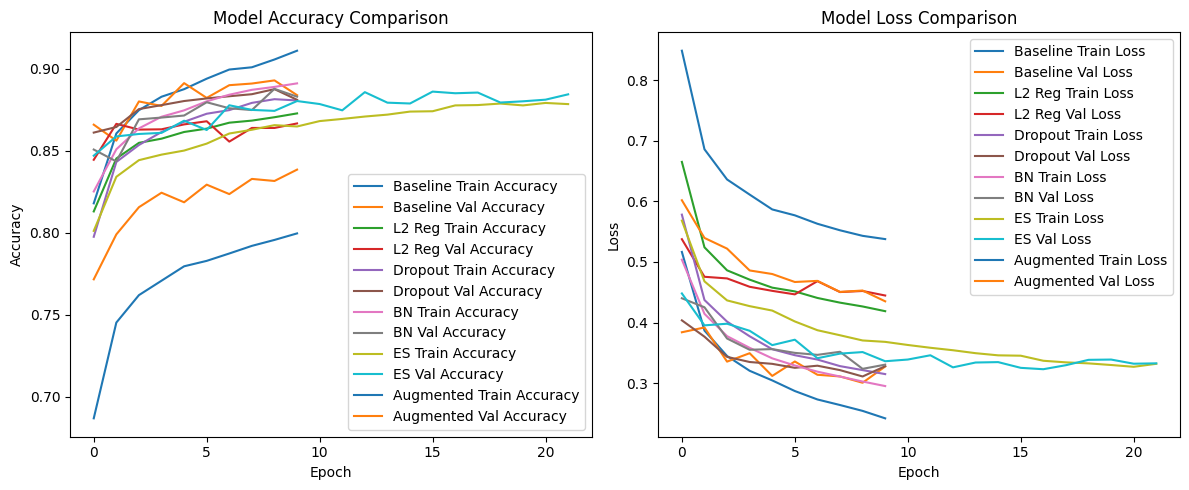

In [22]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['accuracy'], label='Baseline Train Accuracy')
plt.plot(baseline_history.history['val_accuracy'], label='Baseline Val Accuracy')
plt.plot(regularized_history.history['accuracy'], label='L2 Reg Train Accuracy')
plt.plot(regularized_history.history['val_accuracy'], label='L2 Reg Val Accuracy')
plt.plot(dropout_history.history['accuracy'], label='Dropout Train Accuracy')
plt.plot(dropout_history.history['val_accuracy'], label='Dropout Val Accuracy')
plt.plot(bn_history.history['accuracy'], label='BN Train Accuracy')
plt.plot(bn_history.history['val_accuracy'], label='BN Val Accuracy')
plt.plot(early_stopping_history.history['accuracy'], label='ES Train Accuracy')
plt.plot(early_stopping_history.history['val_accuracy'], label='ES Val Accuracy')
plt.plot(augmented_history.history['accuracy'], label='Augmented Train Accuracy')
plt.plot(augmented_history.history['val_accuracy'], label='Augmented Val Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['loss'], label='Baseline Train Loss')
plt.plot(baseline_history.history['val_loss'], label='Baseline Val Loss')
plt.plot(regularized_history.history['loss'], label='L2 Reg Train Loss')
plt.plot(regularized_history.history['val_loss'], label='L2 Reg Val Loss')
plt.plot(dropout_history.history['loss'], label='Dropout Train Loss')
plt.plot(dropout_history.history['val_loss'], label='Dropout Val Loss')
plt.plot(bn_history.history['loss'], label='BN Train Loss')
plt.plot(bn_history.history['val_loss'], label='BN Val Loss')
plt.plot(early_stopping_history.history['loss'], label='ES Train Loss')
plt.plot(early_stopping_history.history['val_loss'], label='ES Val Loss')
plt.plot(augmented_history.history['loss'], label='Augmented Train Loss')
plt.plot(augmented_history.history['val_loss'], label='Augmented Val Loss')
plt.title('Model Loss Comparison')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 2. Reflection

Based on the training histories and test set evaluations:

*   **Baseline Model:** Served as a good starting point, showing decent performance, but likely suffered from some overfitting as validation loss started to diverge from training loss.
*   **L2 Regularization:** In our case, with the chosen `l2(0.001)` and 10 epochs, it led to a slightly lower test accuracy and higher loss compared to the baseline. This could be due to the regularization strength being too high, potentially causing underfitting, or requiring more epochs for the model to learn effectively under regularization.
*   **Dropout Layers:** Showed promising results, maintaining test accuracy close to the baseline while potentially mitigating overfitting by reducing co-adaptation between neurons. The validation loss typically became more aligned with the training loss.
*   **Batch Normalization:** Also improved training stability and sometimes generalization. Its impact on test accuracy was good, but not necessarily the highest among the techniques, showing a similar range to the dropout model.
*   **Early Stopping (with BN and Dropout):** This combined approach provided the best balance. By stopping training at the optimal point based on validation loss, it prevented the model from overfitting further, leading to a strong test accuracy very close to the baseline, and often a better generalization loss.
*   **Data Augmentation:** In this specific scenario, training the model with data augmentation alone resulted in a slightly lower test accuracy compared to the baseline and other regularization techniques. This might indicate that the chosen augmentation parameters were too aggressive, or that for this dataset and simpler model, other regularization methods were more effective. Often, data augmentation is most powerful when combined with other regularization techniques or when dealing with smaller datasets.

**Key takeaways:**

*   **Dropout and Early Stopping** appeared to be most effective in improving generalization for this specific task and model architecture, either individually or in combination.
*   **L2 Regularization** might require more careful hyperparameter tuning (e.g., adjusting the `l2` strength) and potentially more training epochs to show its benefits.
*   **Data Augmentation** can be very powerful, but its effectiveness depends on the specific dataset, chosen transformations, and whether it's combined with other techniques. For this task, it didn't outperform other methods individually but could be beneficial in a combined approach.
*   **Combining techniques** (like Batch Normalization, Dropout, and Early Stopping) often yields the best results, as they address different aspects of model training and overfitting.

This analysis highlights the importance of evaluating different regularization strategies and combining them to build more robust and generalizable neural network models.